<a href="https://colab.research.google.com/github/pranavtakit/delta-demo/blob/main/Another_copy_of_SeasonalAgricultureFP_Vois.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Pranav Takit
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4000
Columns: 28


In [ ]:
print("Columns in the dataset:")
for i, col in enumerate(df.columns, 1):
    print(i, "-", col)

Columns in the dataset:
1 - Farm_ID
2 - State
3 - District
4 - Crop
5 - Season
6 - Farm_Area_Hectares
7 - Rainfall_mm
8 - Avg_Temperature_C
9 - Humidity_pct
10 - Sunlight_Hours_Day
11 - Soil_pH
12 - Soil_Moisture_pct
13 - Nitrogen_kg_ha
14 - Phosphorus_kg_ha
15 - Potassium_kg_ha
16 - Irrigation_Method
17 - Fertilizer_kg_ha
18 - Pesticide_Litre_ha
19 - Seed_Quality_Score
20 - Yield_Tonnes_Ha
21 - Production_Tonnes
22 - Market_Price_INR_Tonne
23 - Total_Cost_INR
24 - Revenue_INR
25 - Profit_INR
26 - Water_Used_m3
27 - Water_Efficiency_t_per_1000m3
28 - Disease_Pest_Risk_pct


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [ ]:
print("States:", df['State'].nunique())
print("Districts:", df['District'].nunique())
print("Crops:", df['Crop'].nunique())
print("Seasons:", df['Season'].nunique())
print("Irrigation Methods:", df['Irrigation_Method'].nunique())

States: 8
Districts: 10
Crops: 8
Seasons: 3
Irrigation Methods: 4


In [ ]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().mean() * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]

display(missing)

,Missing Count,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


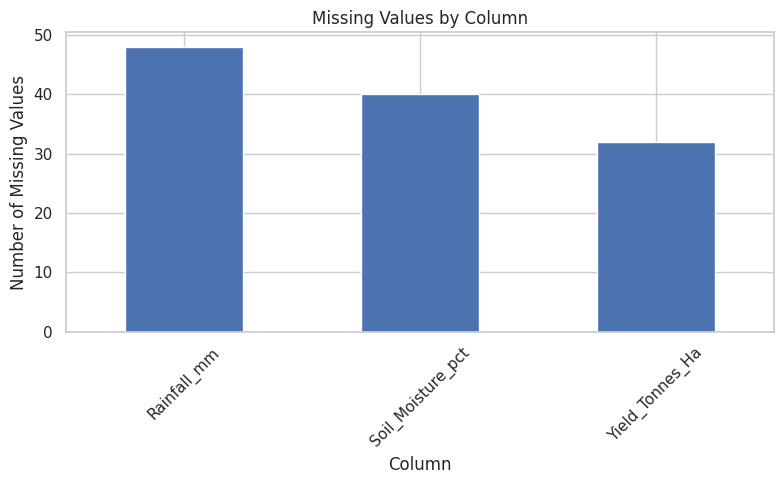

In [ ]:
plt.figure(figsize=(8,5))

missing['Missing Count'].plot(kind='bar')

plt.title('Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

print("Missing values handled successfully.")

Missing values handled successfully.


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
district_state_mapping = {
    'Rajkot': 'Gujarat',
    'Nalgonda': 'Telangana',
    'Warangal': 'Telangana',
    'Indore': 'Madhya Pradesh',
    'Ludhiana': 'Punjab',
    'Raichur': 'Karnataka',
    'Guntur': 'Andhra Pradesh',
    'Krishna': 'Andhra Pradesh',
    'Nashik': 'Maharashtra',
    'Erode': 'Tamil Nadu'
}

# Save original state for comparison
df['Original_State'] = df['State']

# Correct State using District
df['State'] = df['District'].map(district_state_mapping)

# Count corrections
corrections = (df['Original_State'] != df['State']).sum()

print("State values corrected:", corrections)
print("Unmapped districts:", df['State'].isnull().sum())

State values corrected: 3485
Unmapped districts: 0


In [ ]:
state_district_check = (
    df[['State', 'District']]
    .drop_duplicates()
    .sort_values(['State', 'District'])
)

display(state_district_check)

,State,District
8,Andhra Pradesh,Guntur
10,Andhra Pradesh,Krishna
0,Gujarat,Rajkot
5,Karnataka,Raichur
3,Madhya Pradesh,Indore
24,Maharashtra,Nashik
4,Punjab,Ludhiana
41,Tamil Nadu,Erode
1,Telangana,Nalgonda
2,Telangana,Warangal


In [ ]:
df.drop(columns=['Original_State'], inplace=True)

print("Temporary column removed.")
print("Current dataset shape:", df.shape)

Temporary column removed.
Current dataset shape: (4000, 28)


In [ ]:
df['Profit_Margin_pct'] = (
    df['Profit_INR'] / df['Revenue_INR']
) * 100

df['Cost_per_Hectare'] = (
    df['Total_Cost_INR'] / df['Farm_Area_Hectares']
)

df['Revenue_per_Hectare'] = (
    df['Revenue_INR'] / df['Farm_Area_Hectares']
)

df['Profit_per_Hectare'] = (
    df['Profit_INR'] / df['Farm_Area_Hectares']
)

print("New features created successfully.")

New features created successfully.


In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Hectare,Revenue_per_Hectare,Profit_per_Hectare
0,SF10001,Gujarat,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,42662,30810,-11852,237,5.485,55.3,-38.468030,80494.339623,58132.075472,-22362.264151
1,SF10002,Telangana,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,492351,40401,-451950,4953,0.396,49.9,-1118.660429,75398.315467,6186.983155,-69211.332312
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,315210,190466,-124744,1275,1.984,33.7,-65.494104,64858.024691,39190.534979,-25667.489712
3,SF10004,Madhya Pradesh,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,296444,200740,-95704,3834,2.160,50.6,-47.675600,65876.444444,44608.888889,-21267.555556
4,SF10005,Punjab,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,337959,193607,-144352,3287,2.829,32.3,-74.559288,80275.296912,45987.410926,-34287.885986


In [ ]:
print("Crop Distribution:")
display(df['Crop'].value_counts())

Crop Distribution:


,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [ ]:
print("Season Distribution:")
display(df['Season'].value_counts())

Season Distribution:


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [ ]:
print("State Distribution:")
display(df['State'].value_counts())

State Distribution:


,count
State,
Telangana,837
Andhra Pradesh,783
Punjab,427
Tamil Nadu,403
Gujarat,401
Madhya Pradesh,392
Karnataka,386
Maharashtra,371


In [ ]:
print("Irrigation Method Distribution:")
display(df['Irrigation_Method'].value_counts())

Irrigation Method Distribution:


,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


In [ ]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

display(season_summary)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Total_Cost_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,46.31,710719.06,178914.65,531804.41,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,87689.47,513836.58,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,-24804.82,543976.73,6419.89,4.41,38.22


,Average Yield
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


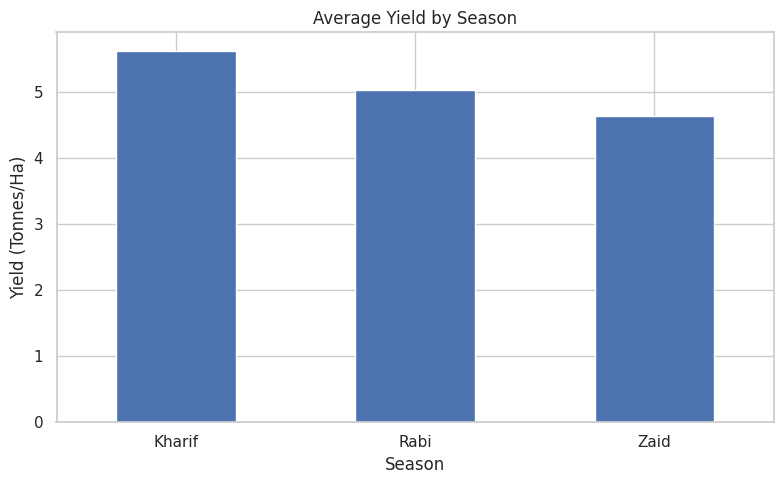

In [ ]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

display(season_yield.to_frame('Average Yield'))

plt.figure(figsize=(8,5))
season_yield.plot(kind='bar')

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Production
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


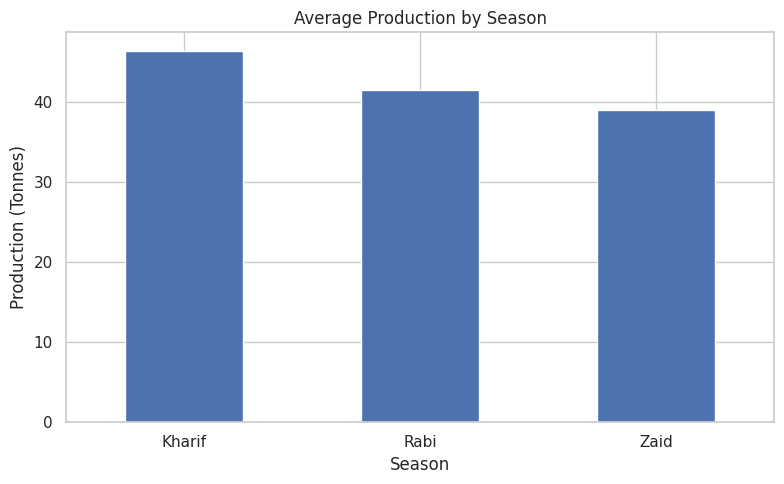

In [ ]:
season_production = df.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False)

display(season_production.to_frame('Average Production'))

plt.figure(figsize=(8,5))
season_production.plot(kind='bar')

plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Revenue
Season,
Kharif,710719.055649
Rabi,601526.048556
Zaid,519171.904040


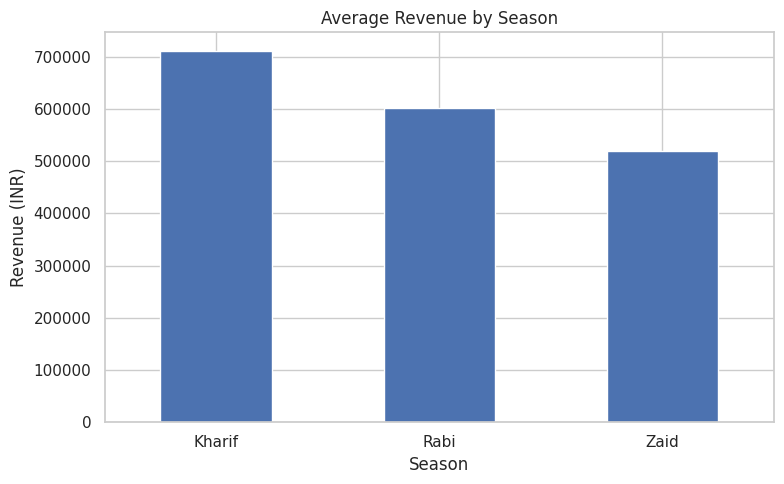

In [ ]:
season_revenue = df.groupby('Season')['Revenue_INR'].mean().sort_values(ascending=False)

display(season_revenue.to_frame('Average Revenue'))

plt.figure(figsize=(8,5))
season_revenue.plot(kind='bar')

plt.title('Average Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Profit
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


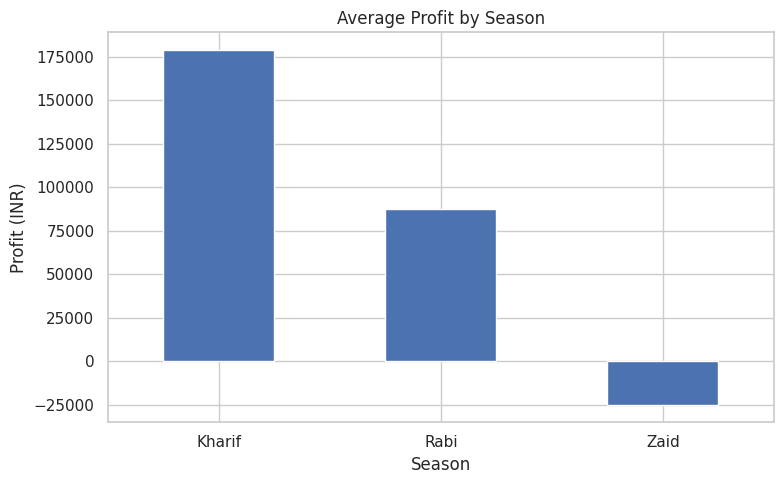

In [ ]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

display(season_profit.to_frame('Average Profit'))

plt.figure(figsize=(8,5))
season_profit.plot(kind='bar')

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Rainfall
Season,
Kharif,849.199663
Rabi,437.615366
Zaid,304.654714


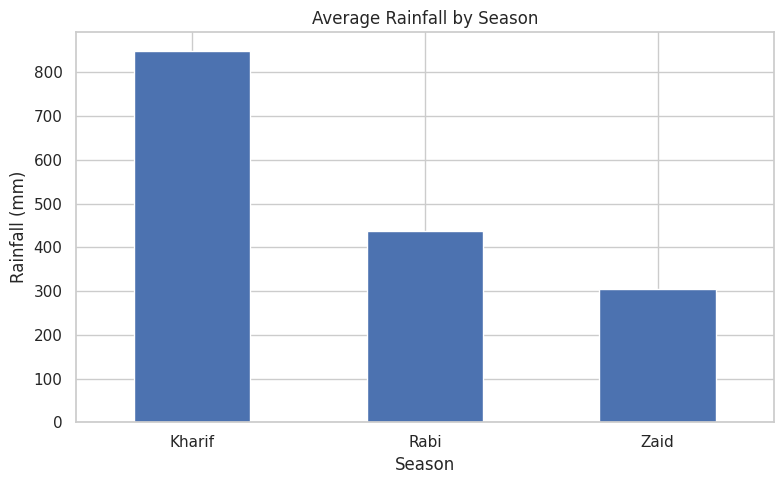

In [ ]:
rainfall_season = df.groupby('Season')['Rainfall_mm'].mean()

display(rainfall_season.to_frame('Average Rainfall'))

plt.figure(figsize=(8,5))
rainfall_season.plot(kind='bar')

plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Temperature
Season,
Kharif,28.454019
Rabi,23.489183
Zaid,31.042088


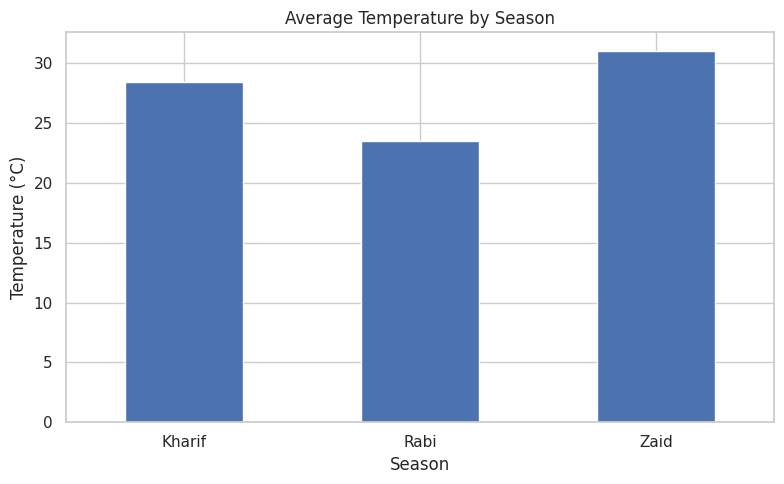

In [ ]:
temperature_season = df.groupby('Season')['Avg_Temperature_C'].mean()

display(temperature_season.to_frame('Average Temperature'))

plt.figure(figsize=(8,5))
temperature_season.plot(kind='bar')

plt.title('Average Temperature by Season')
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Humidity
Season,
Kharif,71.812591
Rabi,57.893178
Zaid,52.012121


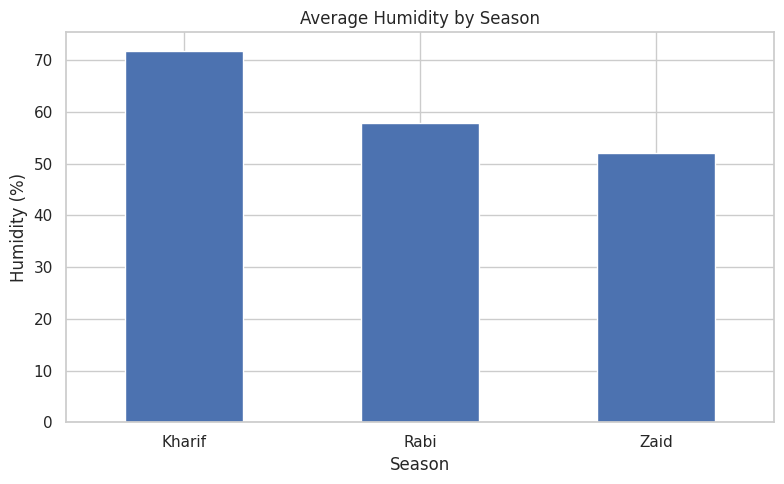

In [ ]:
humidity_season = df.groupby('Season')['Humidity_pct'].mean()

display(humidity_season.to_frame('Average Humidity'))

plt.figure(figsize=(8,5))
humidity_season.plot(kind='bar')

plt.title('Average Humidity by Season')
plt.xlabel('Season')
plt.ylabel('Humidity (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Soil Moisture
Season,
Kharif,31.149859
Rabi,24.069392
Zaid,19.279630


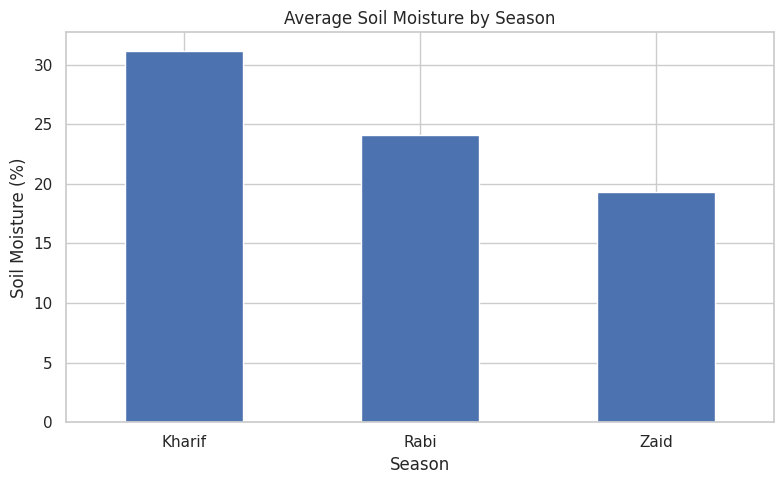

In [ ]:
soil_moisture_season = df.groupby('Season')['Soil_Moisture_pct'].mean()

display(soil_moisture_season.to_frame('Average Soil Moisture'))

plt.figure(figsize=(8,5))
soil_moisture_season.plot(kind='bar')

plt.title('Average Soil Moisture by Season')
plt.xlabel('Season')
plt.ylabel('Soil Moisture (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Fertilizer
Season,
Kharif,187.077965
Rabi,185.407068
Zaid,184.638047


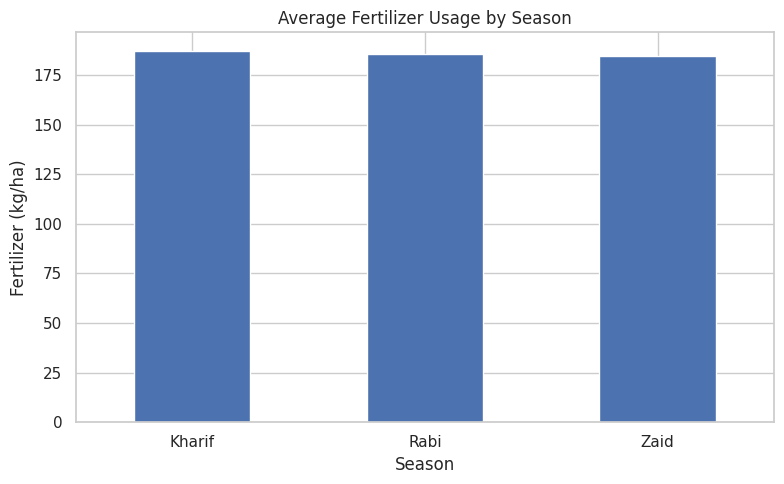

In [ ]:
fertilizer_season = df.groupby('Season')['Fertilizer_kg_ha'].mean()

display(fertilizer_season.to_frame('Average Fertilizer'))

plt.figure(figsize=(8,5))
fertilizer_season.plot(kind='bar')

plt.title('Average Fertilizer Usage by Season')
plt.xlabel('Season')
plt.ylabel('Fertilizer (kg/ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Pesticide
Season,
Kharif,5.079747
Rabi,5.024690
Zaid,5.171212


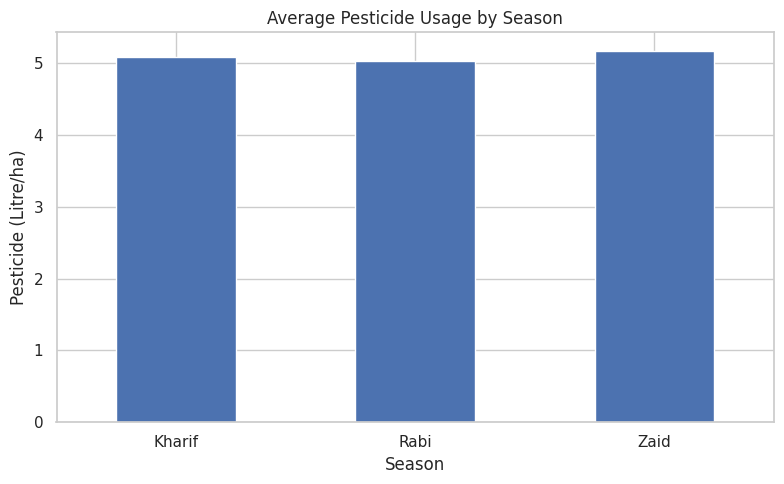

In [ ]:
pesticide_season = df.groupby('Season')['Pesticide_Litre_ha'].mean()

display(pesticide_season.to_frame('Average Pesticide'))

plt.figure(figsize=(8,5))
pesticide_season.plot(kind='bar')

plt.title('Average Pesticide Usage by Season')
plt.xlabel('Season')
plt.ylabel('Pesticide (Litre/ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Water Used
Season,
Kharif,6102.201237
Rabi,5846.987093
Zaid,6419.893939


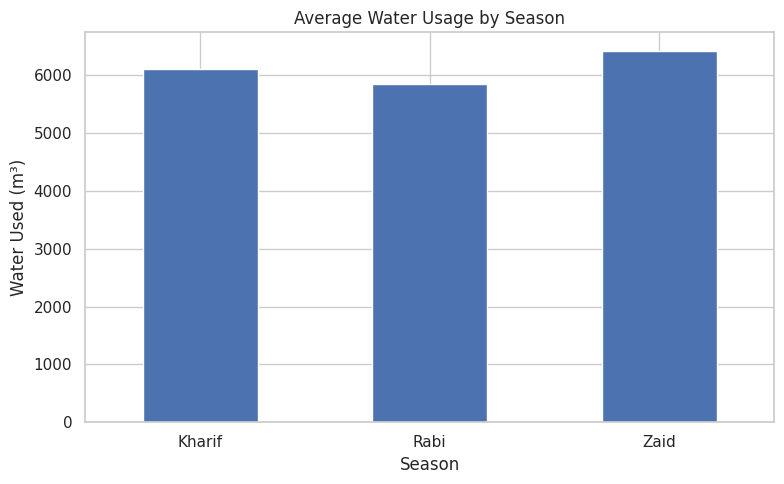

In [ ]:
water_season = df.groupby('Season')['Water_Used_m3'].mean()

display(water_season.to_frame('Average Water Used'))

plt.figure(figsize=(8,5))
water_season.plot(kind='bar')

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Water Efficiency
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


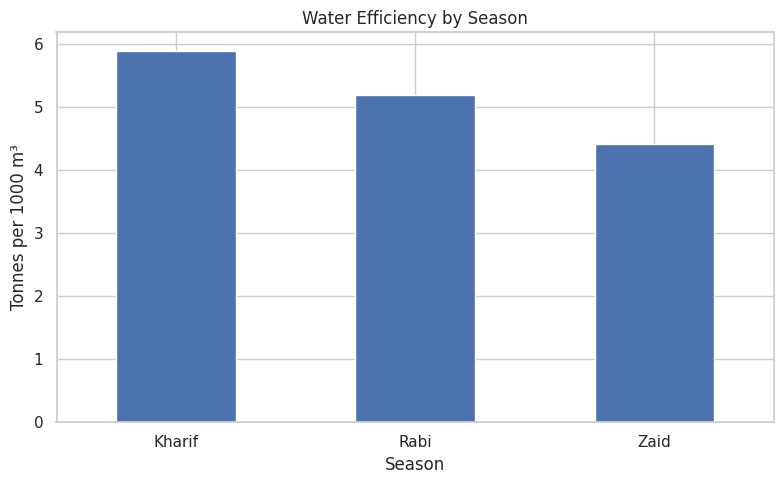

In [ ]:
water_efficiency = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()

display(water_efficiency.to_frame('Water Efficiency'))

plt.figure(figsize=(8,5))
water_efficiency.plot(kind='bar')

plt.title('Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Tonnes per 1000 m³')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Cost
Season,
Kharif,531804.408094
Rabi,513836.578365
Zaid,543976.728956


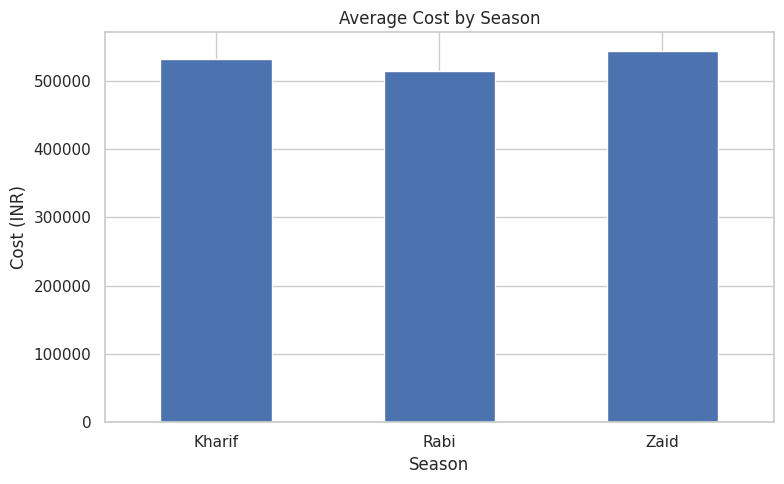

In [ ]:
cost_season = df.groupby('Season')['Total_Cost_INR'].mean()

display(cost_season.to_frame('Average Cost'))

plt.figure(figsize=(8,5))
cost_season.plot(kind='bar')

plt.title('Average Cost by Season')
plt.xlabel('Season')
plt.ylabel('Cost (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Profit Margin
Season,
Kharif,-38.644541
Rabi,-44.267645
Zaid,-69.354573


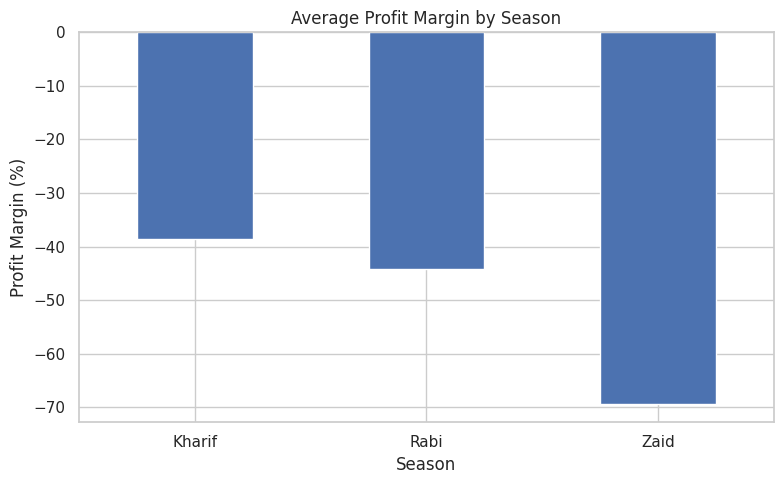

In [ ]:
profit_margin_season = df.groupby('Season')['Profit_Margin_pct'].mean()

display(profit_margin_season.to_frame('Average Profit Margin'))

plt.figure(figsize=(8,5))
profit_margin_season.plot(kind='bar')

plt.title('Average Profit Margin by Season')
plt.xlabel('Season')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
profitable = (df['Profit_INR'] > 0).sum()
loss_making = (df['Profit_INR'] < 0).sum()
break_even = (df['Profit_INR'] == 0).sum()

print("Profitable farms:", profitable)
print("Loss-making farms:", loss_making)
print("Break-even farms:", break_even)

Profitable farms: 2034
Loss-making farms: 1966
Break-even farms: 0


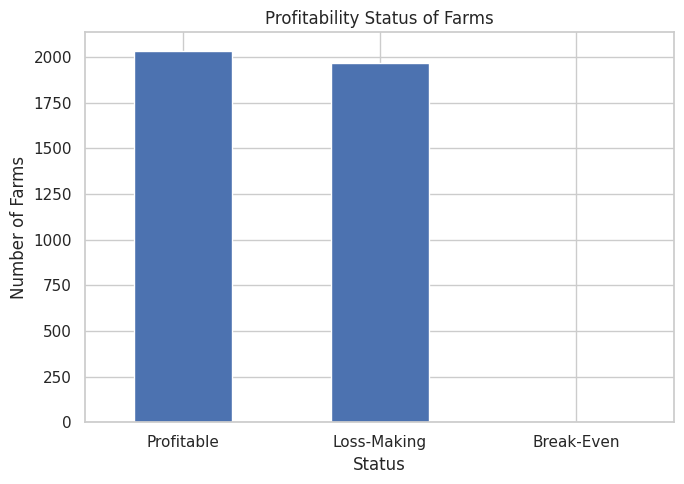

In [ ]:
profit_status = pd.Series({
    'Profitable': profitable,
    'Loss-Making': loss_making,
    'Break-Even': break_even
})

plt.figure(figsize=(7,5))
profit_status.plot(kind='bar')

plt.title('Profitability Status of Farms')
plt.xlabel('Status')
plt.ylabel('Number of Farms')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Yield
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


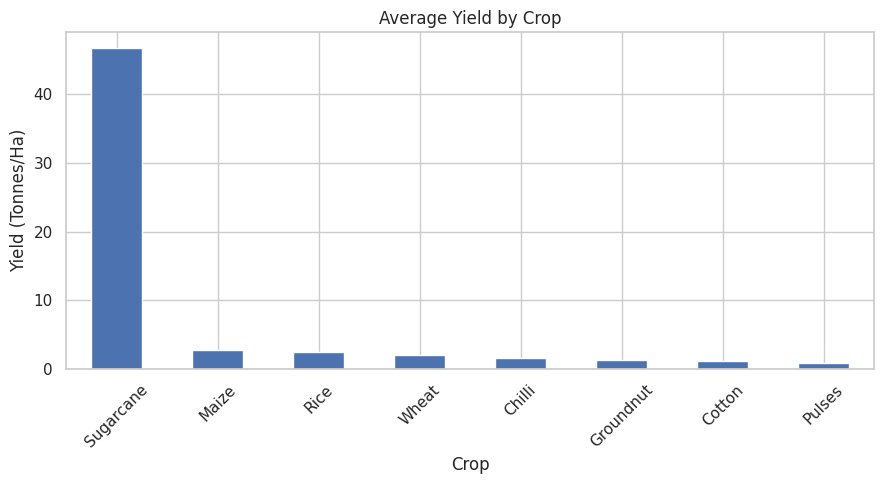

In [ ]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

display(crop_yield.to_frame('Average Yield'))

plt.figure(figsize=(9,5))
crop_yield.plot(kind='bar')

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Average Profit
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


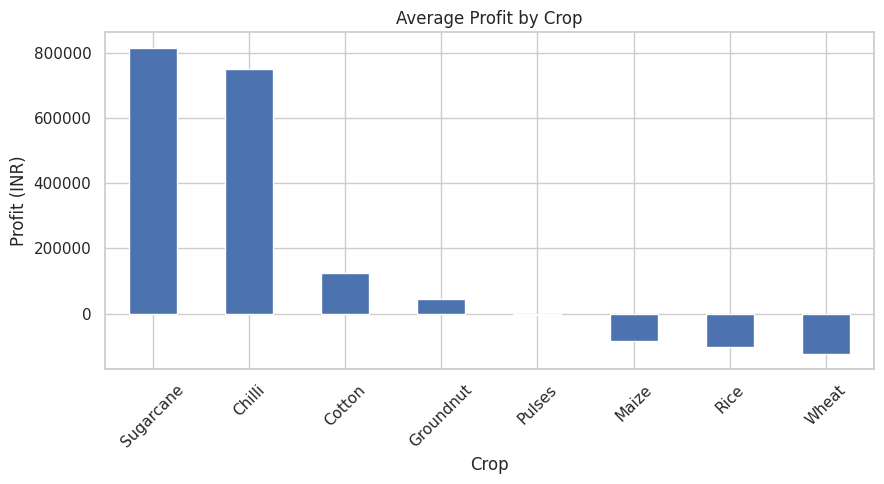

In [ ]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

display(crop_profit.to_frame('Average Profit'))

plt.figure(figsize=(9,5))
crop_profit.plot(kind='bar')

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


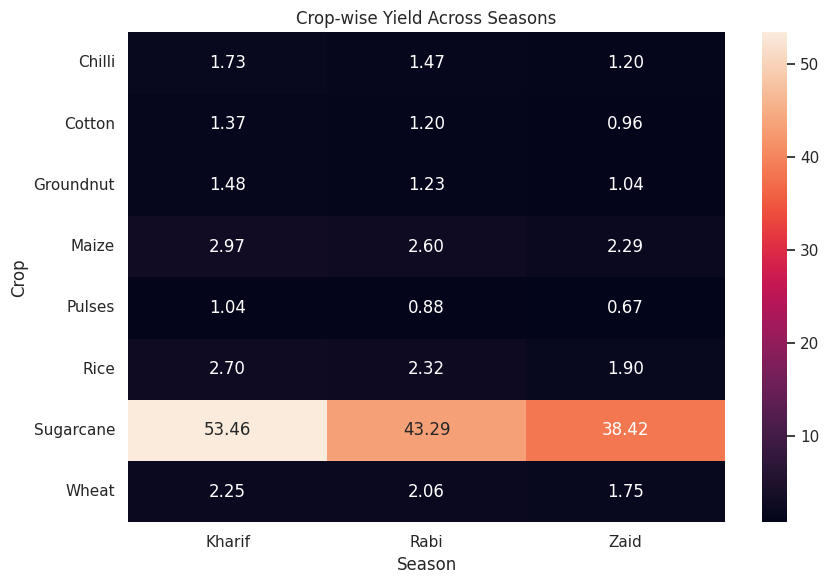

In [ ]:
crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

display(crop_season_yield.round(2))

plt.figure(figsize=(9,6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f'
)

plt.title('Crop-wise Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

,Average Yield
State,
Gujarat,6.020150
Punjab,5.799883
Telangana,5.651039
Andhra Pradesh,5.158774
Karnataka,4.940777
Madhya Pradesh,4.883240
Maharashtra,4.863881
Tamil Nadu,4.177816


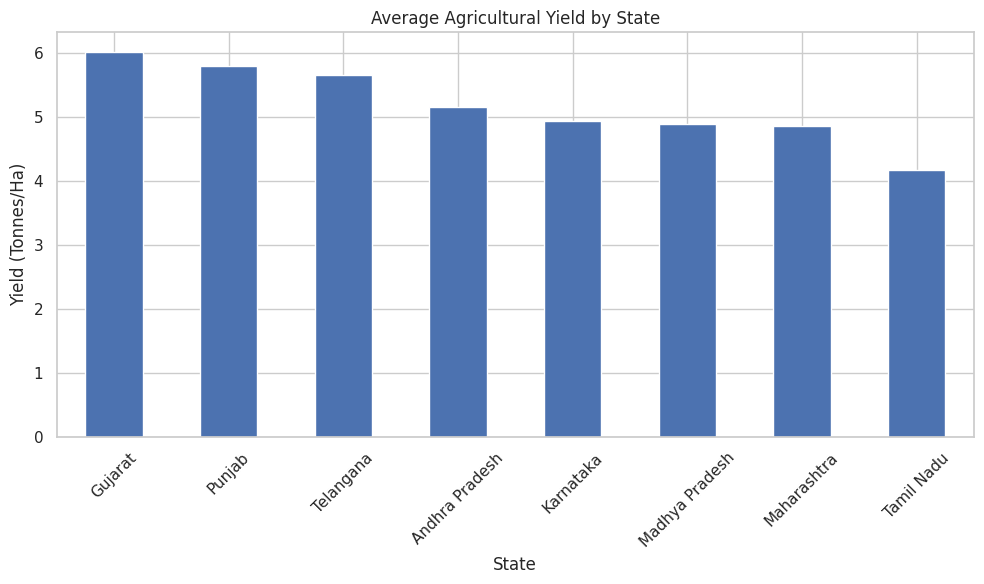

In [ ]:
state_yield = df.groupby('State')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

display(state_yield.to_frame('Average Yield'))

plt.figure(figsize=(10,6))
state_yield.plot(kind='bar')

plt.title('Average Agricultural Yield by State')
plt.xlabel('State')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Average Profit
State,
Telangana,148935.610514
Karnataka,125172.699482
Gujarat,119463.276808
Tamil Nadu,102079.565757
Andhra Pradesh,97253.037037
Maharashtra,94910.172507
Madhya Pradesh,90421.341837
Punjab,87590.831382


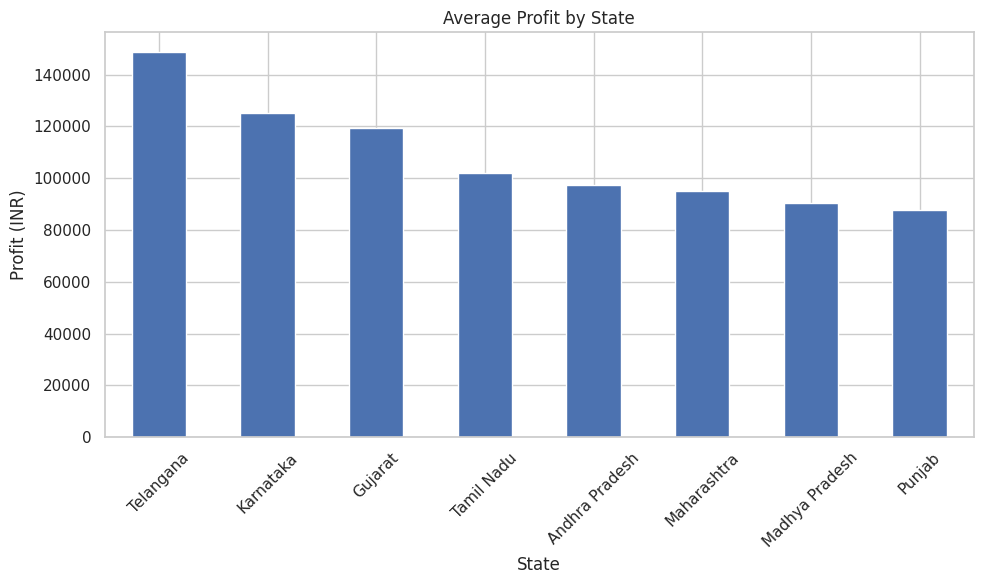

In [ ]:
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)

display(state_profit.to_frame('Average Profit'))

plt.figure(figsize=(10,6))
state_profit.plot(kind='bar')

plt.title('Average Profit by State')
plt.xlabel('State')
plt.ylabel('Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Average Yield
Irrigation_Method,
Drip,6.577989
Sprinkler,5.160627
Flood,4.863977
Rainfed,4.602142


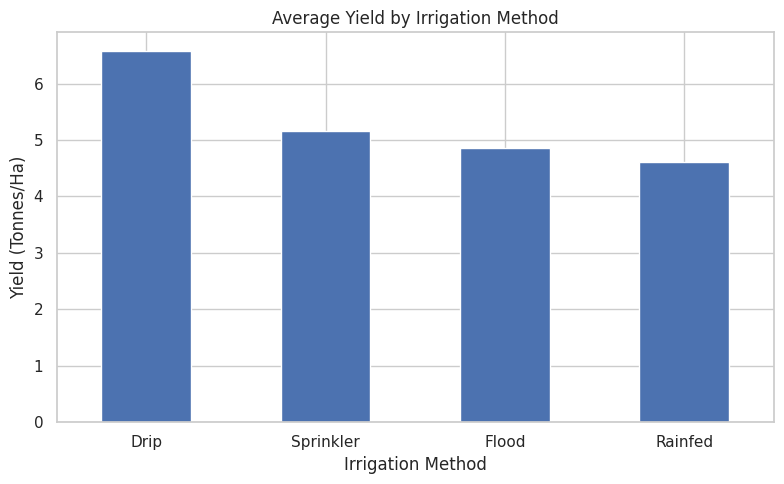

In [ ]:
irrigation_yield = df.groupby(
    'Irrigation_Method'
)['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

display(irrigation_yield.to_frame('Average Yield'))

plt.figure(figsize=(8,5))
irrigation_yield.plot(kind='bar')

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Profit
Irrigation_Method,
Drip,219625.997814
Sprinkler,91121.079019
Rainfed,79050.365034
Flood,73354.022901


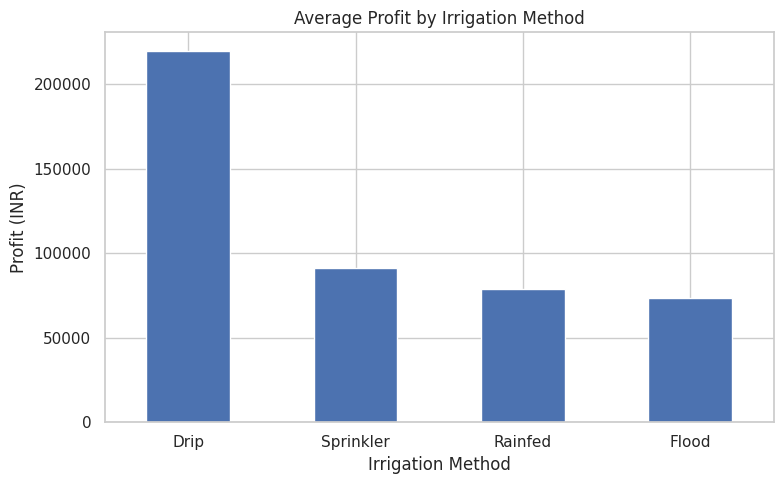

In [ ]:
irrigation_profit = df.groupby(
    'Irrigation_Method'
)['Profit_INR'].mean().sort_values(ascending=False)

display(irrigation_profit.to_frame('Average Profit'))

plt.figure(figsize=(8,5))
irrigation_profit.plot(kind='bar')

plt.title('Average Profit by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Profit (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Average Disease/Pest Risk
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


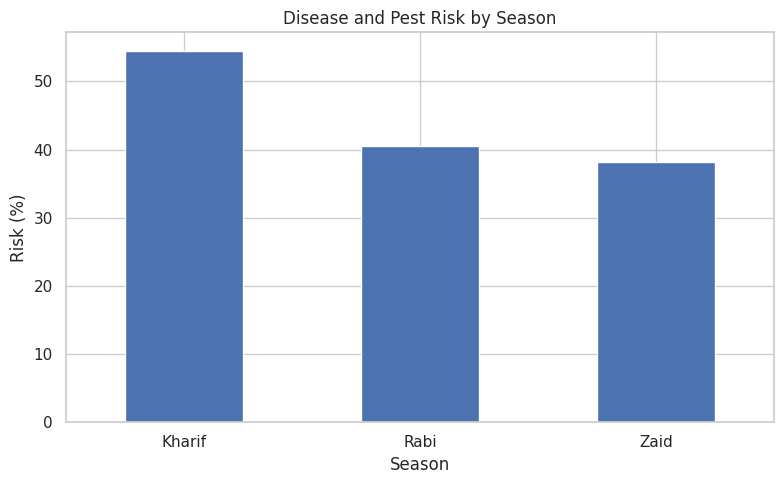

In [ ]:
risk_season = df.groupby('Season')['Disease_Pest_Risk_pct'].mean()

display(risk_season.to_frame('Average Disease/Pest Risk'))

plt.figure(figsize=(8,5))
risk_season.plot(kind='bar')

plt.title('Disease and Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Risk (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

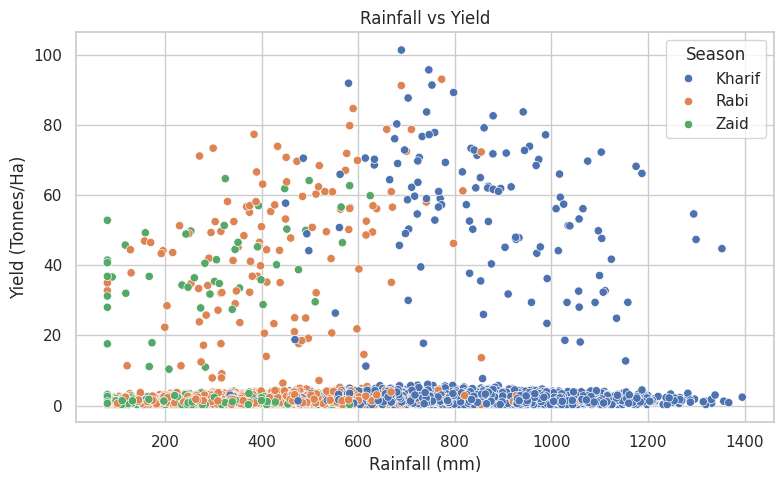

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

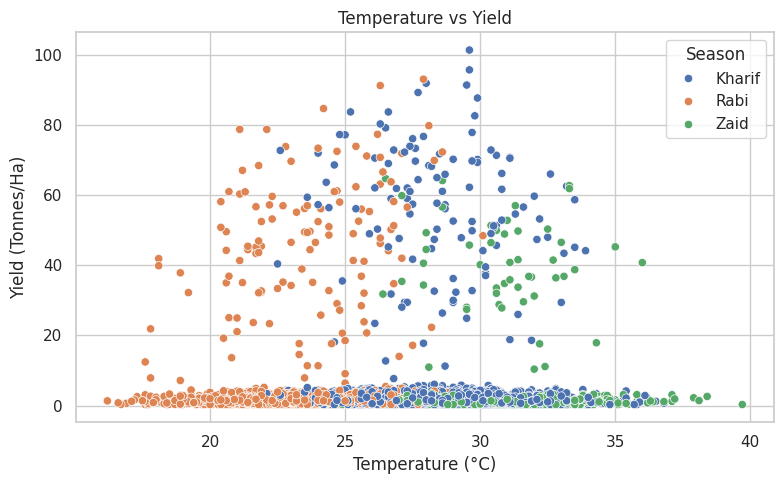

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Temperature vs Yield')
plt.xlabel('Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

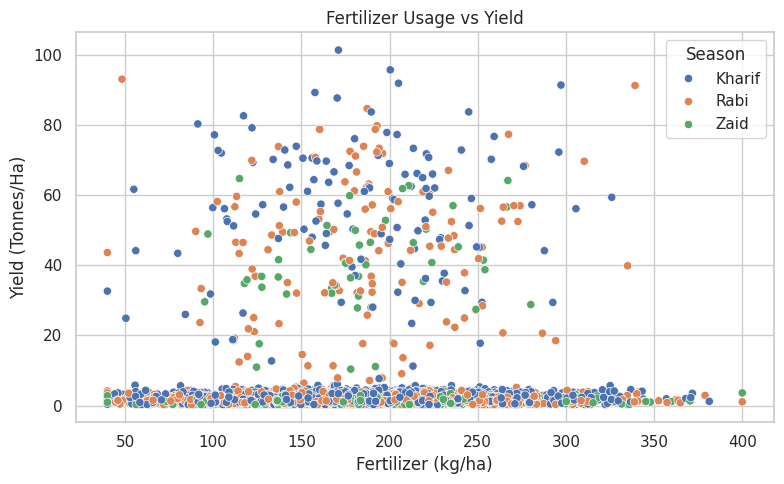

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Fertilizer Usage vs Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

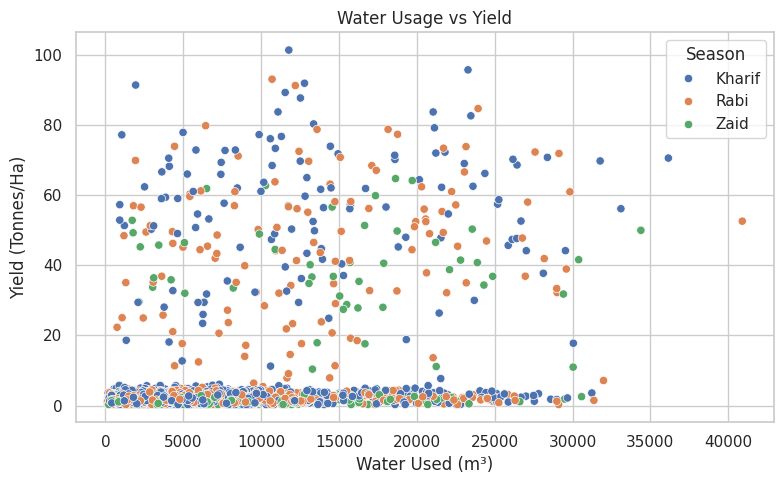

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Water Usage vs Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

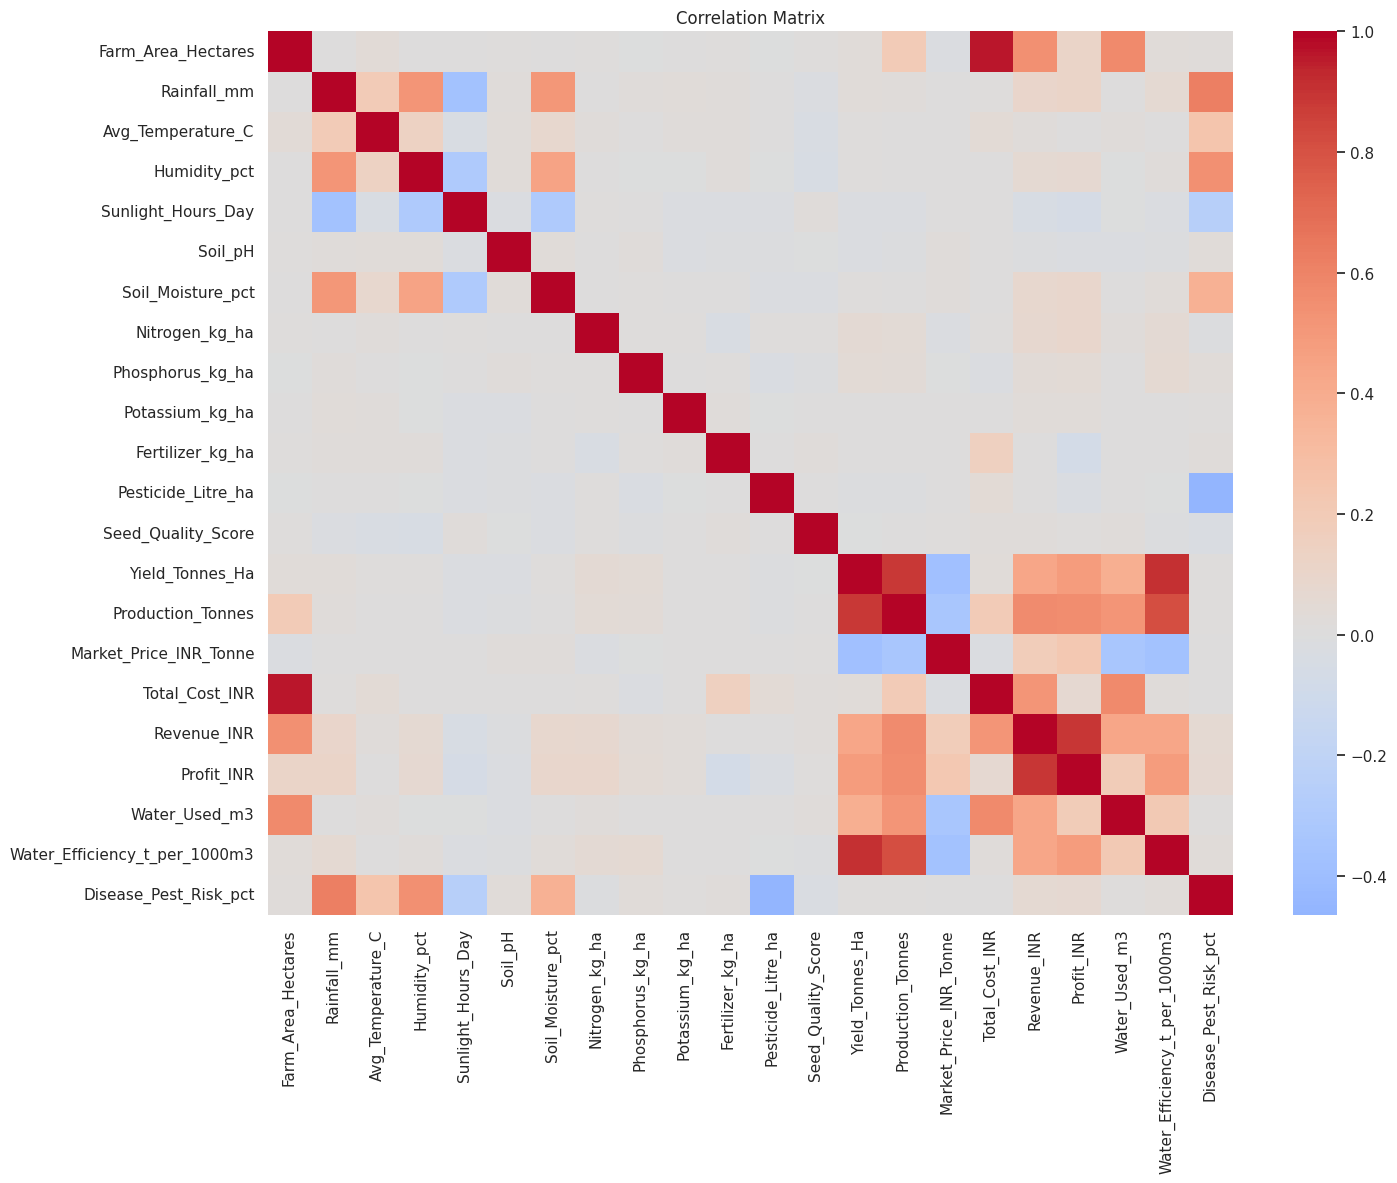

In [ ]:
numeric_cols = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(15,12))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
yield_correlation = (
    correlation['Yield_Tonnes_Ha']
    .sort_values(ascending=False)
)

display(yield_correlation.to_frame('Correlation with Yield'))

,Correlation with Yield
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


In [ ]:
best_yield_season = season_yield.idxmax()
worst_yield_season = season_yield.idxmin()

best_profit_season = season_profit.idxmax()
worst_profit_season = season_profit.idxmin()

best_water_season = water_efficiency.idxmax()

print("Best season for yield:", best_yield_season)
print("Worst season for yield:", worst_yield_season)

print("Best season for profit:", best_profit_season)
print("Worst season for profit:", worst_profit_season)

print("Best season for water efficiency:", best_water_season)

Best season for yield: Kharif
Worst season for yield: Zaid
Best season for profit: Kharif
Worst season for profit: Zaid
Best season for water efficiency: Kharif


In [ ]:
crop_season_results = (
    df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 Crop-Season combinations by Yield:")
display(crop_season_results.head(10).to_frame('Average Yield'))

Top 10 Crop-Season combinations by Yield:


Average Yield
Crop      Season               
Sugarcane Kharif      53.459120
          Rabi        43.286124
          Zaid        38.423922
Maize     Kharif       2.966410
Rice      Kharif       2.698376
Maize     Rabi         2.603648
Rice      Rabi         2.322847
Maize     Zaid         2.290952
Wheat     Kharif       2.253664
          Rabi         2.057468

In [ ]:
crop_season_profit = (
    df.groupby(['Crop', 'Season'])['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 Crop-Season combinations by Profit:")
display(crop_season_profit.head(10).to_frame('Average Profit'))

Top 10 Crop-Season combinations by Profit:


,,Average Profit
Crop,Season,
Sugarcane,Kharif,1.000791e+06
Chilli,Kharif,9.543804e+05
Sugarcane,Rabi,7.316129e+05
Chilli,Rabi,6.385725e+05
Sugarcane,Zaid,5.836358e+05
Chilli,Zaid,4.486591e+05
Cotton,Kharif,2.169995e+05
Groundnut,Kharif,1.082654e+05
Cotton,Rabi,1.073436e+05


In [ ]:
final_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

display(final_summary)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Total_Cost_INR,Rainfall_mm,Avg_Temperature_C,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,
Kharif,5.63,46.31,710719.06,178914.65,531804.41,849.20,28.45,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,87689.47,513836.58,437.62,23.49,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,-24804.82,543976.73,304.65,31.04,6419.89,4.41,38.22


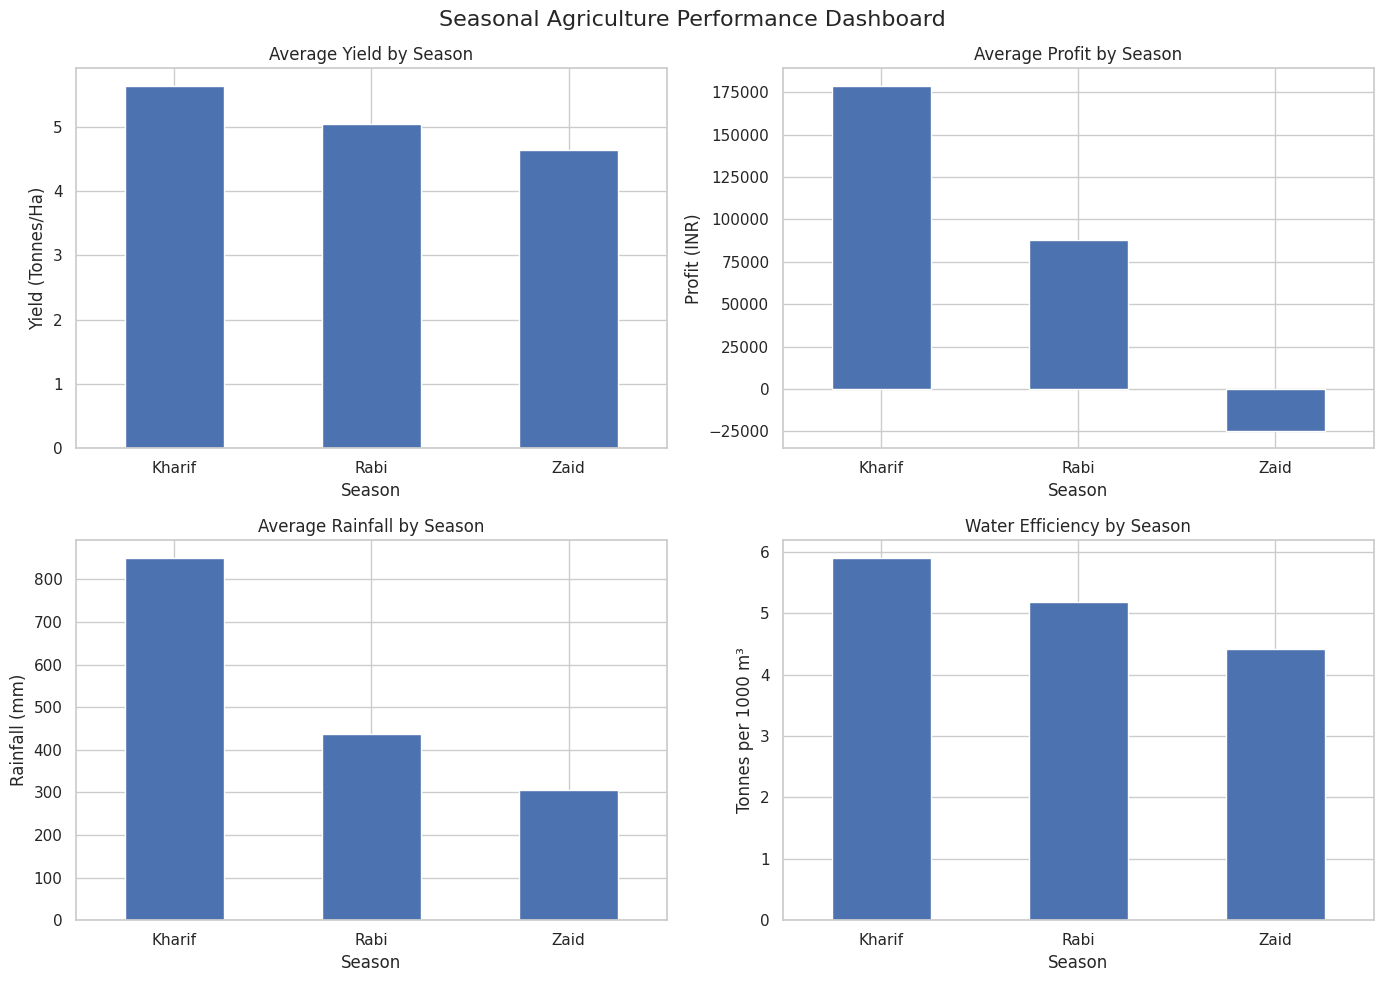

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Yield
season_yield.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Average Yield by Season')
axes[0,0].set_ylabel('Yield (Tonnes/Ha)')
axes[0,0].tick_params(axis='x', rotation=0)

# Profit
season_profit.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Average Profit by Season')
axes[0,1].set_ylabel('Profit (INR)')
axes[0,1].tick_params(axis='x', rotation=0)

# Rainfall
rainfall_season.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Average Rainfall by Season')
axes[1,0].set_ylabel('Rainfall (mm)')
axes[1,0].tick_params(axis='x', rotation=0)

# Water Efficiency
water_efficiency.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Water Efficiency by Season')
axes[1,1].set_ylabel('Tonnes per 1000 m³')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle(
    'Seasonal Agriculture Performance Dashboard',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
print("FINAL DATA QUALITY CHECK")
print("=" * 40)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Unique districts:", df['District'].nunique())
print("Unique states:", df['State'].nunique())

print("\nState-District mismatches:")

correct_mapping = df['District'].map(district_state_mapping)

mismatches = (df['State'] != correct_mapping).sum()

print(mismatches)

FINAL DATA QUALITY CHECK
Rows: 4000
Columns: 32
Missing values: 0
Duplicate rows: 0
Unique districts: 10
Unique states: 8

State-District mismatches:
0


In [ ]:
df.to_csv(
    'cleaned_seasonal_agriculture_dataset.csv',
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
from google.colab import files

files.download('cleaned_seasonal_agriculture_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>